## Datasets

### Reuters-21578 Dataset Loading


In [13]:
import os
import pandas as pd
from bs4 import BeautifulSoup
from collections import Counter
import re

# Set path to reuters data directory
reuters_dir = "data/reuters"

def parse_reuters_sgm(file_path):
    """Parse a Reuters SGML file and extract documents."""
    with open(file_path, 'r', encoding='latin-1', errors='ignore') as f:
        content = f.read()
    
    # Fix malformed SGML
    content = content.replace('<!DOCTYPE lewis SYSTEM "lewis.dtd">', '')
    content = '<ROOT>' + content + '</ROOT>'
    
    soup = BeautifulSoup(content, 'html.parser')
    documents = []
    
    for doc in soup.find_all('reuters'):
        doc_dict = {}
        
        # Get attributes
        doc_dict['newid'] = doc.get('newid', '')
        doc_dict['lewissplit'] = doc.get('lewissplit', '')
        doc_dict['cgisplit'] = doc.get('cgisplit', '')
        doc_dict['oldid'] = doc.get('oldid', '')
        doc_dict['topics_attribute'] = doc.get('topics', '')
        
        # Extract topics
        topics_tag = doc.find('topics')
        if topics_tag:
            doc_dict['topics'] = [d.text for d in topics_tag.find_all('d')]
        else:
            doc_dict['topics'] = []
        
        # Extract places
        places_tag = doc.find('places')
        if places_tag:
            doc_dict['places'] = [d.text for d in places_tag.find_all('d')]
        else:
            doc_dict['places'] = []
        
        # Extract people
        people_tag = doc.find('people')
        if people_tag:
            doc_dict['people'] = [d.text for d in people_tag.find_all('d')]
        else:
            doc_dict['people'] = []
        
        # Extract orgs
        orgs_tag = doc.find('orgs')
        if orgs_tag:
            doc_dict['orgs'] = [d.text for d in orgs_tag.find_all('d')]
        else:
            doc_dict['orgs'] = []
        
        # Extract exchanges
        exchanges_tag = doc.find('exchanges')
        if exchanges_tag:
            doc_dict['exchanges'] = [d.text for d in exchanges_tag.find_all('d')]
        else:
            doc_dict['exchanges'] = []
        
        # Extract text content
        date_tag = doc.find('date')
        doc_dict['date'] = date_tag.text if date_tag else ''
        
        dateline_tag = doc.find('dateline')
        doc_dict['dateline'] = dateline_tag.text if dateline_tag else ''
        
        title_tag = doc.find('title')
        doc_dict['title'] = title_tag.text if title_tag else ''
        
        body_tag = doc.find('body')
        doc_dict['body'] = body_tag.text if body_tag else ''
        
        # Combine title and body for full text
        doc_dict['text'] = f"{doc_dict['title']} {doc_dict['body']}".strip()
        
        documents.append(doc_dict)
    
    return documents

# Load all Reuters SGML files
all_documents = []

sgm_files = sorted([f for f in os.listdir(reuters_dir) if f.startswith('reut2-') and f.endswith('.sgm')])
print(f"Found {len(sgm_files)} SGML files")

for filename in sgm_files:
    file_path = os.path.join(reuters_dir, filename)
    print(f"Processing {filename}...")
    docs = parse_reuters_sgm(file_path)
    all_documents.extend(docs)
    print(f"  Extracted {len(docs)} documents")

print(f"\nTotal documents extracted: {len(all_documents)}")

# Convert to DataFrame
df_reuters = pd.DataFrame(all_documents)
print(f"DataFrame shape: {df_reuters.shape}")
print(f"Columns: {list(df_reuters.columns)}")


Found 22 SGML files
Processing reut2-000.sgm...
  Extracted 1000 documents
Processing reut2-001.sgm...
  Extracted 1000 documents
Processing reut2-002.sgm...
  Extracted 1000 documents
Processing reut2-003.sgm...
  Extracted 1000 documents
Processing reut2-004.sgm...
  Extracted 1000 documents
Processing reut2-005.sgm...
  Extracted 1000 documents
Processing reut2-006.sgm...
  Extracted 1000 documents
Processing reut2-007.sgm...
  Extracted 1000 documents
Processing reut2-008.sgm...
  Extracted 1000 documents
Processing reut2-009.sgm...
  Extracted 1000 documents
Processing reut2-010.sgm...
  Extracted 1000 documents
Processing reut2-011.sgm...
  Extracted 1000 documents
Processing reut2-012.sgm...
  Extracted 1000 documents
Processing reut2-013.sgm...
  Extracted 1000 documents
Processing reut2-014.sgm...
  Extracted 1000 documents
Processing reut2-015.sgm...
  Extracted 1000 documents
Processing reut2-016.sgm...
  Extracted 1000 documents
Processing reut2-017.sgm...
  Extracted 1000 

In [18]:
# Display dataset overview
print(f"DataFrame shape: {df_reuters.shape}")
print(f"\nColumns: {list(df_reuters.columns)}")
print(f"\nFirst few rows:")
df_reuters.head()

DataFrame shape: (21578, 15)

Columns: ['newid', 'lewissplit', 'cgisplit', 'oldid', 'topics_attribute', 'topics', 'places', 'people', 'orgs', 'exchanges', 'date', 'dateline', 'title', 'body', 'text']

First few rows:


,newid,lewissplit,cgisplit,oldid,topics_attribute,topics,places,people,orgs,exchanges,date,dateline,title,body,text
0,1,TRAIN,TRAINING-SET,5544,YES,[cocoa],"[el-salvador, usa, uruguay]",[],[],[],26-FEB-1987 15:01:01.79,"SALVADOR, Feb 26 -",BAHIA COCOA REVIEW,Showers continued throughout the week in\nthe ...,BAHIA COCOA REVIEW Showers continued throughou...
1,2,TRAIN,TRAINING-SET,5545,NO,[],[usa],[],[],[],26-FEB-1987 15:02:20.00,"CLEVELAND, Feb 26 -",STANDARD OIL <SRD> TO FORM FINANCIAL UNIT,Standard Oil Co and BP North America\nInc said...,STANDARD OIL <SRD> TO FORM FINANCIAL UNIT Stan...
2,3,TRAIN,TRAINING-SET,5546,NO,[],[usa],[],[],[],26-FEB-1987 15:03:27.51,"HOUSTON, Feb 26 -",TEXAS COMMERCE BANCSHARES <TCB> FILES PLAN,Texas Commerce Bancshares Inc's Texas\nCommerc...,TEXAS COMMERCE BANCSHARES <TCB> FILES PLAN Tex...
3,4,TRAIN,TRAINING-SET,5547,NO,[],"[usa, brazil]",[],[],[],26-FEB-1987 15:07:13.72,"LOS ANGELES, Feb 26 -",TALKING POINT/BANKAMERICA <BAC> EQUITY OFFER,BankAmerica Corp is not under\npressure to act...,TALKING POINT/BANKAMERICA <BAC> EQUITY OFFER B...
4,5,TRAIN,TRAINING-SET,5548,YES,"[grain, wheat, corn, barley, oat, sorghum]",[usa],[],[],[],26-FEB-1987 15:10:44.60,"WASHINGTON, Feb 26 -",NATIONAL AVERAGE PRICES FOR FARMER-OWNED RESERVE,The U.S. Agriculture Department\nreported the ...,NATIONAL AVERAGE PRICES FOR FARMER-OWNED RESER...


### Commodities

#### Directly Retrievable

In [15]:
# pip install yfinance pandas
import yfinance as yf
import pandas as pd

start = "2008-01-01"
end   = "2009-01-01"  # exclusive

symbols = {
    # Energy
    "crude": "CL=F",
    "nat-gas": "NG=F",
    "heat": "HO=F",
    "gas": "RB=F",
    "fuel_proxy": "HO=F",
    "jet_proxy": "HO=F",

    # Metals
    "gold": "GC=F",
    "silver": "SI=F",
    "copper": "HG=F",
    "platinum": "PL=F",
    "palladium": "PA=F",

    # Grains
    "wheat": "ZW=F",
    "corn": "ZC=F",
    "oat": "ZO=F",
    "soybean": "ZS=F",
    "soy-oil": "ZL=F",
    "soy-meal": "ZM=F",
    "rice": "F*ZR.CBT",

    # Softs
    "cocoa": "CC=F",
    "coffee": "KC=F",
    "sugar": "SB=F",
    "cotton": "CT=F",
    "orange": "OJ=F",

    # Livestock
    "l-cattle": "LE=F",
    "f-cattle": "GF=F",
    "hog": "HE=F",

    # FX / indices
    "dlr_index": "DX-Y.NYB",
    "yen": "JPY=X",
    "saudriyal": "SAR=X",
    "austdlr": "AUD=X",
    "nzdlr": "NZD=X",
    "rand": "ZAR=X",
    "ringgit": "MYR=X",
    "rupiah": "IDR=X",
    "skr": "SEK=X",
    "nkr": "NOK=X",
    "dkr": "DKK=X",
    "hk": "HKD=X",
    "sfr": "CHF=X",

    # Legacy replacements
    "eur": "EUR=X",
    "brl": "BRL=X",
}

availability = []
series = {}

for name, sym in symbols.items():
    df = yf.download(sym, start=start, end=end, interval="1d", progress=False)
    df = df.dropna(how="all")
    availability.append({
        "name": name,
        "symbol": sym,
        "rows_2008": int(df.shape[0]),
        "first_date": (df.index.min().date().isoformat() if not df.empty else None),
        "last_date": (df.index.max().date().isoformat() if not df.empty else None),
    })
    if not df.empty:
        # prefer Adj Close if present, else Close
        col = "Adj Close" if "Adj Close" in df.columns else "Close"
        series[name] = df[col]

avail_df = pd.DataFrame(availability).sort_values(["rows_2008", "name"], ascending=[False, True])
avail_df.to_csv("availability_2008_yahoo.csv", index=False)

# Create wide DataFrame only if we have data
if series:
    wide = pd.DataFrame(series)
    wide.to_csv("prices_2008_yahoo_wide.csv", index=True)
    print(avail_df)
    print(f"\nSaved: availability_2008_yahoo.csv and prices_2008_yahoo_wide.csv")
    print(f"Successfully downloaded {len(series)} assets with data")
else:
    print(avail_df)
    print("\nSaved: availability_2008_yahoo.csv")
    print("⚠ Warning: No price data was downloaded. All downloads failed or returned empty data.")
    print("This may be due to Yahoo Finance API issues or invalid ticker symbols.")

$F*ZR.CBT: possibly delisted; no timezone found

1 Failed download:
['F*ZR.CBT']: possibly delisted; no timezone found


ValueError: If using all scalar values, you must pass an index

## Explorative Data analysis

In [19]:
# Count topic frequencies
from collections import Counter

all_topics = []
for topics_list in df_reuters['topics']:
    all_topics.extend(topics_list)

topic_counts = Counter(all_topics)
print(f"Total unique topics: {len(topic_counts)}")
print(f"\nTop 20 most common topics:")
for topic in topic_counts:
    print(f"  {topic}")

Total unique topics: 120

Top 20 most common topics:
  cocoa
  grain
  wheat
  corn
  barley
  oat
  sorghum
  veg-oil
  linseed
  lin-oil
  soy-oil
  sun-oil
  soybean
  oilseed
  sunseed
  earn
  acq
  copper
  housing
  money-supply
  coffee
  ship
  sugar
  trade
  reserves
  meal-feed
  soy-meal
  rye
  cotton
  carcass
  livestock
  crude
  nat-gas
  cpi
  gnp
  money-fx
  interest
  bop
  rice
  red-bean
  rubber
  copra-cake
  palm-oil
  palmkernel
  tea
  plywood
  alum
  gold
  platinum
  strategic-metal
  tapioca
  tin
  rapeseed
  groundnut-oil
  rape-oil
  cornglutenfeed
  citruspulp
  rape-meal
  wool
  dlr
  l-cattle
  retail
  ipi
  silver
  iron-steel
  hog
  propane
  heat
  gas
  jobs
  lei
  yen
  saudriyal
  zinc
  orange
  pet-chem
  fuel
  wpi
  potato
  lead
  groundnut
  can
  fishmeal
  income
  palladium
  nickel
  lumber
  jet
  instal-debt
  dfl
  dmk
  stg
  coconut-oil
  corn-oil
  inventories
  cpu
  peseta
  austdlr
  cotton-oil
  naphtha
  nzdlr
  rand

In [20]:
# Filter for actual tradeable commodities (exclude financial/economic indicators and currencies)
# These are the commodity topics that actually have price data

actual_commodities = {
    # Energy
    'crude', 'nat-gas', 'gas', 'heat', 'fuel', 'propane', 'jet', 'naphtha',
    
    # Metals
    'copper', 'gold', 'platinum', 'silver', 'alum', 'tin', 'zinc', 'lead', 
    'nickel', 'palladium', 'strategic-metal', 'iron-steel',
    
    # Grains
    'wheat', 'corn', 'barley', 'oat', 'sorghum', 'rice', 'rye', 'grain',
    
    # Oilseeds & Oils
    'soybean', 'soy-oil', 'soy-meal', 'rapeseed', 'rape-oil', 'rape-meal',
    'sunseed', 'sun-oil', 'sun-meal', 'linseed', 'lin-oil', 'lin-meal',
    'palm-oil', 'palmkernel', 'groundnut', 'groundnut-oil', 'corn-oil',
    'cottonseed', 'cotton-oil', 'castor-oil', 'castorseed', 'coconut-oil',
    'veg-oil', 'oilseed',
    
    # Softs
    'coffee', 'cocoa', 'sugar', 'cotton', 'orange', 'rubber', 'tea', 'wool',
    
    # Livestock & Meats
    'livestock', 'l-cattle', 'f-cattle', 'hog', 'carcass', 'pork-belly',
    
    # Other Agricultural
    'lumber', 'plywood', 'potato', 'red-bean', 'tapioca',
    
    # Meals & Feeds
    'meal-feed', 'fishmeal', 'copra-cake', 'cornglutenfeed', 'citruspulp'
}

# Filter topic_counts to only include actual commodities
commodity_topic_counts = {topic: count for topic, count in topic_counts.items() 
                         if topic in actual_commodities}

print(f"Actual tradeable commodities: {len(commodity_topic_counts)}")
print(f"\nTop 30 commodities by document count:")
for topic, count in sorted(commodity_topic_counts.items(), key=lambda x: x[1], reverse=True)[:30]:
    print(f"  {topic}: {count} documents")

# Save commodity list for price extraction
commodity_list = sorted(commodity_topic_counts.keys(), key=lambda x: commodity_topic_counts[x], reverse=True)

Actual tradeable commodities: 76

Top 30 commodities by document count:
  crude: 634 documents
  grain: 628 documents
  wheat: 306 documents
  corn: 254 documents
  oilseed: 192 documents
  sugar: 184 documents
  coffee: 145 documents
  veg-oil: 137 documents
  gold: 135 documents
  nat-gas: 130 documents
  soybean: 120 documents
  livestock: 114 documents
  copper: 78 documents
  cocoa: 76 documents
  carcass: 75 documents
  rice: 67 documents
  iron-steel: 67 documents
  gas: 65 documents
  cotton: 63 documents
  alum: 63 documents
  barley: 54 documents
  meal-feed: 51 documents
  rubber: 51 documents
  zinc: 44 documents
  palm-oil: 43 documents
  silver: 37 documents
  sorghum: 35 documents
  rapeseed: 35 documents
  lead: 35 documents
  tin: 33 documents


In [21]:
# Examine the dataset
print("Dataset Info:")
print(f"Total documents: {len(df_reuters)}")
print(f"\nLewissplit distribution:")
print(df_reuters['lewissplit'].value_counts())
print(f"\nTopics attribute distribution:")
print(df_reuters['topics_attribute'].value_counts())
print(f"\nNumber of documents with at least one topic: {df_reuters['topics'].apply(len).gt(0).sum()}")

Dataset Info:
Total documents: 21578

Lewissplit distribution:
lewissplit
TRAIN       14668
TEST         6188
NOT-USED      722
Name: count, dtype: int64

Topics attribute distribution:
topics_attribute
YES       13476
NO         7059
BYPASS     1043
Name: count, dtype: int64

Number of documents with at least one topic: 11367


In [27]:
# Convert to DataFrame
df_reuters = pd.DataFrame(all_documents)
print(f"DataFrame shape: {df_reuters.shape}")
df_reuters.head()

DataFrame shape: (21578, 15)


,newid,lewissplit,cgisplit,oldid,topics_attribute,topics,places,people,orgs,exchanges,date,dateline,title,body,text
0,1,TRAIN,TRAINING-SET,5544,YES,[cocoa],"[el-salvador, usa, uruguay]",[],[],[],26-FEB-1987 15:01:01.79,"SALVADOR, Feb 26 -",BAHIA COCOA REVIEW,Showers continued throughout the week in\nthe ...,BAHIA COCOA REVIEW Showers continued throughou...
1,2,TRAIN,TRAINING-SET,5545,NO,[],[usa],[],[],[],26-FEB-1987 15:02:20.00,"CLEVELAND, Feb 26 -",STANDARD OIL <SRD> TO FORM FINANCIAL UNIT,Standard Oil Co and BP North America\nInc said...,STANDARD OIL <SRD> TO FORM FINANCIAL UNIT Stan...
2,3,TRAIN,TRAINING-SET,5546,NO,[],[usa],[],[],[],26-FEB-1987 15:03:27.51,"HOUSTON, Feb 26 -",TEXAS COMMERCE BANCSHARES <TCB> FILES PLAN,Texas Commerce Bancshares Inc's Texas\nCommerc...,TEXAS COMMERCE BANCSHARES <TCB> FILES PLAN Tex...
3,4,TRAIN,TRAINING-SET,5547,NO,[],"[usa, brazil]",[],[],[],26-FEB-1987 15:07:13.72,"LOS ANGELES, Feb 26 -",TALKING POINT/BANKAMERICA <BAC> EQUITY OFFER,BankAmerica Corp is not under\npressure to act...,TALKING POINT/BANKAMERICA <BAC> EQUITY OFFER B...
4,5,TRAIN,TRAINING-SET,5548,YES,"[grain, wheat, corn, barley, oat, sorghum]",[usa],[],[],[],26-FEB-1987 15:10:44.60,"WASHINGTON, Feb 26 -",NATIONAL AVERAGE PRICES FOR FARMER-OWNED RESERVE,The U.S. Agriculture Department\nreported the ...,NATIONAL AVERAGE PRICES FOR FARMER-OWNED RESER...


In [28]:
# Load all Reuters SGML files
all_documents = []

sgm_files = sorted([f for f in os.listdir(reuters_dir) if f.startswith('reut2-') and f.endswith('.sgm')])
print(f"Found {len(sgm_files)} SGML files")

for filename in sgm_files:
    file_path = os.path.join(reuters_dir, filename)
    print(f"Processing {filename}...")
    docs = parse_reuters_sgm(file_path)
    all_documents.extend(docs)
    print(f"  Extracted {len(docs)} documents")

print(f"\nTotal documents extracted: {len(all_documents)}")

Found 22 SGML files
Processing reut2-000.sgm...
  Extracted 1000 documents
Processing reut2-001.sgm...
  Extracted 1000 documents
Processing reut2-002.sgm...
  Extracted 1000 documents
Processing reut2-003.sgm...
  Extracted 1000 documents
Processing reut2-004.sgm...
  Extracted 1000 documents
Processing reut2-005.sgm...
  Extracted 1000 documents
Processing reut2-006.sgm...
  Extracted 1000 documents
Processing reut2-007.sgm...
  Extracted 1000 documents
Processing reut2-008.sgm...
  Extracted 1000 documents
Processing reut2-009.sgm...
  Extracted 1000 documents
Processing reut2-010.sgm...
  Extracted 1000 documents
Processing reut2-011.sgm...
  Extracted 1000 documents
Processing reut2-012.sgm...
  Extracted 1000 documents
Processing reut2-013.sgm...
  Extracted 1000 documents
Processing reut2-014.sgm...
  Extracted 1000 documents
Processing reut2-015.sgm...
  Extracted 1000 documents
Processing reut2-016.sgm...
  Extracted 1000 documents
Processing reut2-017.sgm...
  Extracted 1000 

In [29]:
# Extract dates from newid (format: NNNN where first digits indicate document number)
# The Reuters-21578 corpus was collected over time, let's analyze by document order
import matplotlib.pyplot as plt

# Check a sample of datelines to see date format
print("Sample datelines:")
print(df_reuters[df_reuters['dateline'] != '']['dateline'].head(20))
print("\n" + "="*80 + "\n")

Sample datelines:
0                        SALVADOR, Feb 26 - 
1                       CLEVELAND, Feb 26 - 
2                         HOUSTON, Feb 26 - 
3                     LOS ANGELES, Feb 26 - 
4                      WASHINGTON, Feb 26 - 
5                    BUENOS AIRES, Feb 26 - 
6                  PORTLAND, Ore., Feb 26 - 
7                        NEW YORK, Feb 26 - 
8                 ROCHESTER, N.Y., Feb 26 - 
9                   COMMACK, N.Y., Feb 26 - 
10        SANTA CRUZ, Calif., Feb 26 -\n    
11                      CLEVELAND, Feb 26 - 
12                   CHICAGO, Feb 26 -\n    
13           LOUISVILLE, Ky., Feb 26 -\n    
14                     PITTSBURGH, Feb 26 - 
15                    LOS ANGELES, Feb 26 - 
16                 PHOENIX, Ariz., Feb 26 - 
17                        CHICAGO, Feb 26 - 
18                     WASHINGTON, Feb 26 - 
19                     WASHINGTON, Feb 26 - 
Name: dateline, dtype: object




In [30]:
# Summary statistics by month
print("\nDocuments per month with topics:")
monthly_doc_counts = df_with_dates.groupby('month').size()
print(monthly_doc_counts)

print("\n" + "="*80)
print("Topic diversity over time (number of unique topics per month):")
topic_diversity = df_with_dates.groupby('month')['topics'].apply(
    lambda x: len(set([t for topics in x for t in topics]))
)
print(topic_diversity)


Documents per month with topics:


NameError: name 'df_with_dates' is not defined

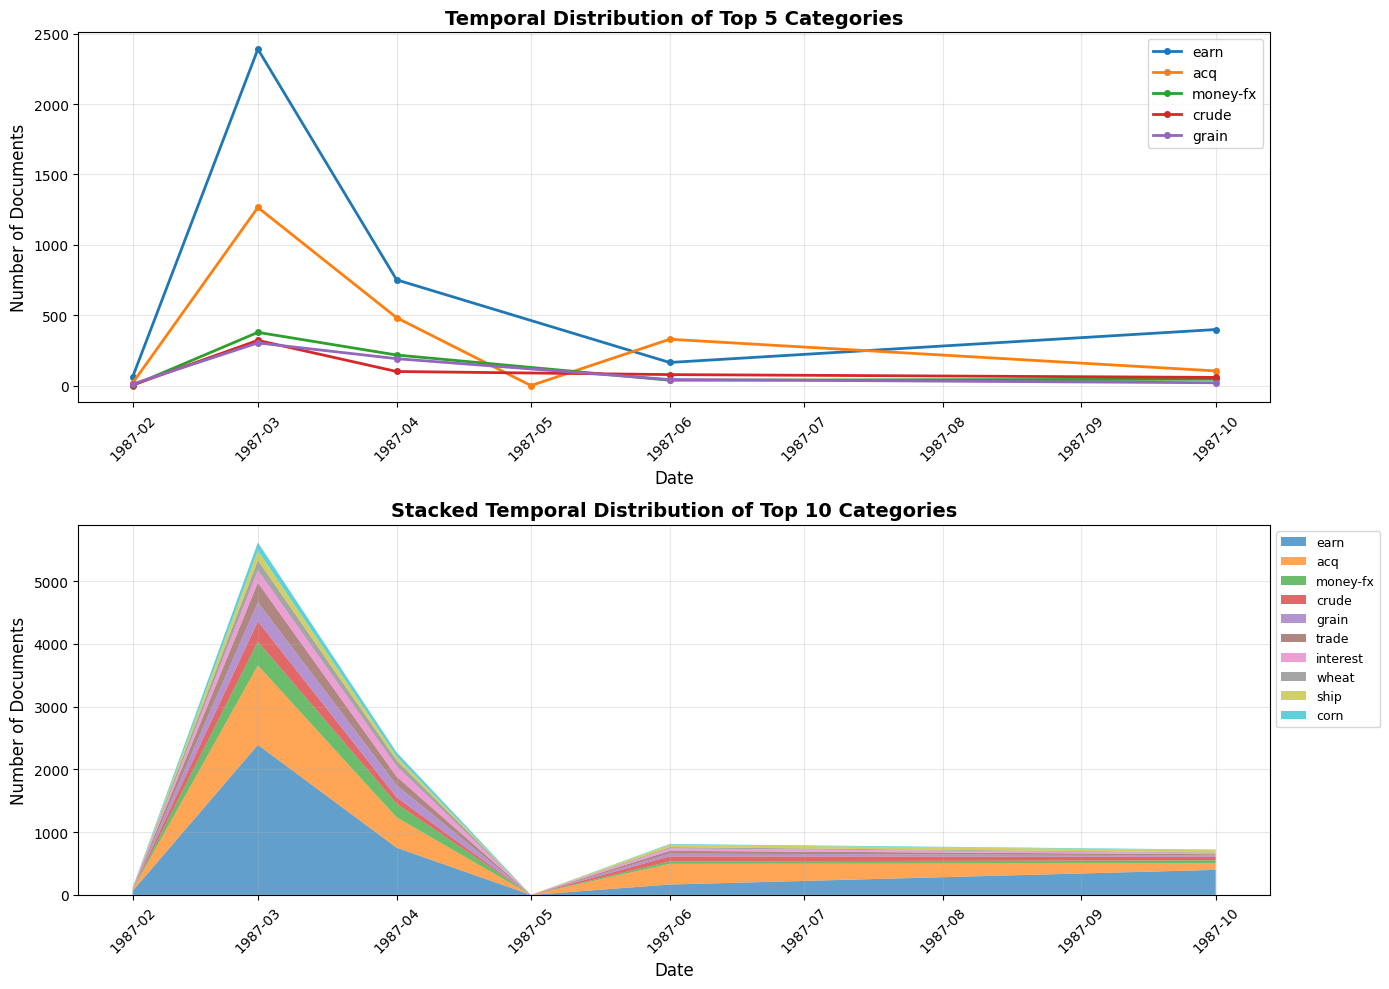

In [ ]:
# Temporal distribution of top categories
# Get top 10 topics
top_topics = topic_counts.most_common(10)
top_topic_names = [t[0] for t in top_topics]

# Filter documents with dates and at least one topic
df_with_dates = df_reuters[df_reuters['date'].notna()].copy()

# Create month-year column for grouping
df_with_dates['month'] = df_with_dates['date'].dt.to_period('M')

# For each top topic, count documents per month
topic_temporal_data = {}
for topic_name in top_topic_names:
    # Create a boolean column for this topic
    df_with_dates[f'has_{topic_name}'] = df_with_dates['topics'].apply(lambda x: topic_name in x)
    # Group by month and count
    monthly_counts = df_with_dates[df_with_dates[f'has_{topic_name}']].groupby('month').size()
    topic_temporal_data[topic_name] = monthly_counts

# Plot temporal distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Line plot of top 5 topics over time
ax1 = axes[0]
for i, topic_name in enumerate(top_topic_names[:5]):
    if topic_name in topic_temporal_data and len(topic_temporal_data[topic_name]) > 0:
        data = topic_temporal_data[topic_name]
        ax1.plot(data.index.to_timestamp(), data.values, marker='o', label=topic_name, linewidth=2, markersize=4)

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Documents', fontsize=12)
ax1.set_title('Temporal Distribution of Top 5 Categories', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Stacked area chart for top 10 topics
ax2 = axes[1]
# Prepare data for stacked area
all_months = sorted(set().union(*[set(data.index) for data in topic_temporal_data.values()]))
stacked_data = []
for topic_name in top_topic_names:
    if topic_name in topic_temporal_data:
        data = topic_temporal_data[topic_name].reindex(all_months, fill_value=0)
        stacked_data.append(data.values)

if stacked_data and all_months:
    timestamps = [m.to_timestamp() for m in all_months]
    ax2.stackplot(timestamps, *stacked_data, labels=top_topic_names, alpha=0.7)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Number of Documents', fontsize=12)
    ax2.set_title('Stacked Temporal Distribution of Top 10 Categories', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Extract date from dateline using regex
import re
from datetime import datetime

def extract_date_from_dateline(dateline):
    """Extract date from Reuters dateline."""
    if not dateline or pd.isna(dateline):
        return None
    
    # Common date patterns in Reuters datelines
    # Examples: "LONDON, March 3", "WASHINGTON, Feb 26", etc.
    months = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12,
        'january': 1, 'february': 2, 'march': 3, 'april': 4, 'june': 6,
        'july': 7, 'august': 8, 'september': 9, 'october': 10, 'november': 11, 'december': 12
    }
    
    # Pattern: Month Day or Month DD
    pattern = r'(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\s+(\d{1,2})'
    match = re.search(pattern, dateline.lower())
    
    if match:
        month_str = match.group(1)
        day = int(match.group(2))
        month = months.get(month_str)
        if month:
            # Reuters-21578 is from 1987, use that as default year
            return datetime(1987, month, min(day, 28))  # cap day at 28 to avoid invalid dates
    
    return None

# Apply date extraction
df_reuters['date'] = df_reuters['dateline'].apply(extract_date_from_dateline)
print(f"Successfully extracted dates for {df_reuters['date'].notna().sum()} out of {len(df_reuters)} documents")
print(f"\nDate range: {df_reuters['date'].min()} to {df_reuters['date'].max()}")

Successfully extracted dates for 18925 out of 21578 documents

Date range: 1987-01-28 00:00:00 to 1987-10-28 00:00:00


In [ ]:
# Count place/location frequencies
from collections import Counter

all_places = []
for places_list in df_reuters['places']:
    all_places.extend(places_list)

place_counts = Counter(all_places)
print(f"Total unique places: {len(place_counts)}")
print(f"\nTop 20 most common places:")
for place, count in place_counts.most_common(20):
    print(f"  {place}: {count}")

Total unique places: 147

Top 20 most common places:
  usa: 12542
  uk: 1489
  japan: 1138
  canada: 1104
  west-germany: 567
  france: 469
  brazil: 332
  australia: 270
  china: 223
  ussr: 216
  switzerland: 214
  belgium: 214
  netherlands: 196
  iran: 179
  italy: 170
  hong-kong: 142
  philippines: 136
  taiwan: 128
  spain: 115
  south-africa: 113


In [ ]:
# Summary statistics for locations
print("\nLocation diversity over time (number of unique places per month):")
place_diversity = df_with_dates.groupby('month')['places'].apply(
    lambda x: len(set([p for places in x for p in places]))
)
print(place_diversity)

print("\n" + "="*80)
print("\nTop locations by month (March 1987 - peak activity):")
march_data = df_with_dates[df_with_dates['month'] == '1987-03']
march_places = []
for places_list in march_data['places']:
    march_places.extend(places_list)
march_place_counts = Counter(march_places)
for place, count in march_place_counts.most_common(15):
    print(f"  {place}: {count}")


Location diversity over time (number of unique places per month):
month
1987-01      1
1987-02     28
1987-03    134
1987-04    115
1987-05      5
1987-06    110
1987-07      1
1987-10     71
Freq: M, Name: places, dtype: int64


Top locations by month (March 1987 - peak activity):
  usa: 6857
  uk: 872
  canada: 596
  japan: 533
  west-germany: 302
  france: 251
  brazil: 201
  australia: 154
  belgium: 136
  china: 128
  switzerland: 122
  ussr: 121
  netherlands: 101
  italy: 89
  iran: 84


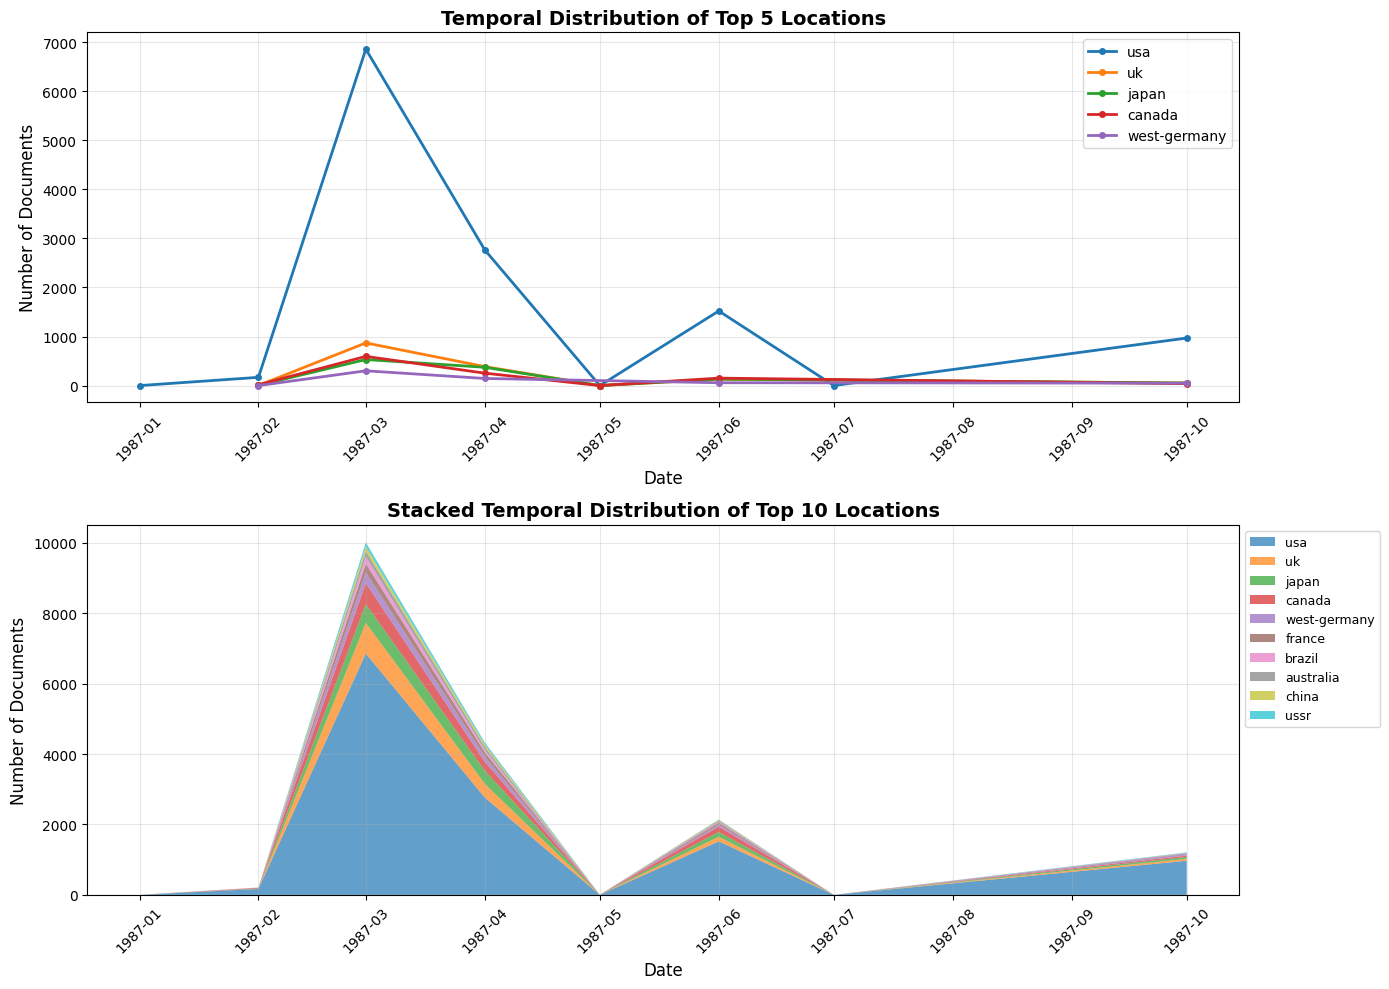

In [ ]:
# Temporal distribution of top locations
# Get top 10 places
top_places = place_counts.most_common(10)
top_place_names = [p[0] for p in top_places]

# For each top place, count documents per month
place_temporal_data = {}
for place_name in top_place_names:
    # Create a boolean column for this place
    df_with_dates[f'has_place_{place_name}'] = df_with_dates['places'].apply(lambda x: place_name in x)
    # Group by month and count
    monthly_counts = df_with_dates[df_with_dates[f'has_place_{place_name}']].groupby('month').size()
    place_temporal_data[place_name] = monthly_counts

# Plot temporal distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Line plot of top 5 places over time
ax1 = axes[0]
for i, place_name in enumerate(top_place_names[:5]):
    if place_name in place_temporal_data and len(place_temporal_data[place_name]) > 0:
        data = place_temporal_data[place_name]
        ax1.plot(data.index.to_timestamp(), data.values, marker='o', label=place_name, linewidth=2, markersize=4)

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Documents', fontsize=12)
ax1.set_title('Temporal Distribution of Top 5 Locations', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Stacked area chart for top 10 places
ax2 = axes[1]
# Prepare data for stacked area
all_months_places = sorted(set().union(*[set(data.index) for data in place_temporal_data.values()]))
stacked_data_places = []
for place_name in top_place_names:
    if place_name in place_temporal_data:
        data = place_temporal_data[place_name].reindex(all_months_places, fill_value=0)
        stacked_data_places.append(data.values)

if stacked_data_places and all_months_places:
    timestamps_places = [m.to_timestamp() for m in all_months_places]
    ax2.stackplot(timestamps_places, *stacked_data_places, labels=top_place_names, alpha=0.7)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Number of Documents', fontsize=12)
    ax2.set_title('Stacked Temporal Distribution of Top 10 Locations', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate category specialization by country
# Shows which countries have higher proportion of specific categories

print("Category Specialization by Country")
print("="*80)
print("\nShowing categories where each country has >20% of global coverage:\n")

for country in top_countries:
    country_specialties = []
    topic_dist = country_topic_distribution[country]
    
    for topic, country_count in topic_dist.most_common(20):
        # Get global count for this topic
        global_count = topic_counts[topic]
        if global_count > 0:
            percentage = (country_count / global_count) * 100
            if percentage > 20:  # Country has >20% of global coverage for this topic
                country_specialties.append((topic, country_count, percentage))
    
    if country_specialties:
        print(f"{country.upper()}:")
        for topic, count, pct in country_specialties:
            print(f"  {topic}: {count} docs ({pct:.1f}% of global {topic} coverage)")
        print()

Category Specialization by Country

Showing categories where each country has >20% of global coverage:

USA:
  earn: 3200 docs (80.3% of global earn coverage)
  acq: 1865 docs (76.2% of global acq coverage)
  grain: 365 docs (58.1% of global grain coverage)
  trade: 314 docs (56.9% of global trade coverage)
  crude: 298 docs (47.0% of global crude coverage)
  money-fx: 238 docs (29.7% of global money-fx coverage)
  wheat: 186 docs (60.8% of global wheat coverage)
  corn: 168 docs (66.1% of global corn coverage)
  interest: 167 docs (32.6% of global interest coverage)
  ship: 118 docs (38.7% of global ship coverage)
  nat-gas: 94 docs (72.3% of global nat-gas coverage)
  oilseed: 93 docs (48.4% of global oilseed coverage)
  livestock: 85 docs (74.6% of global livestock coverage)
  soybean: 82 docs (68.3% of global soybean coverage)
  dlr: 79 docs (36.4% of global dlr coverage)
  money-supply: 75 docs (39.5% of global money-supply coverage)
  carcass: 50 docs (66.7% of global carcass cov

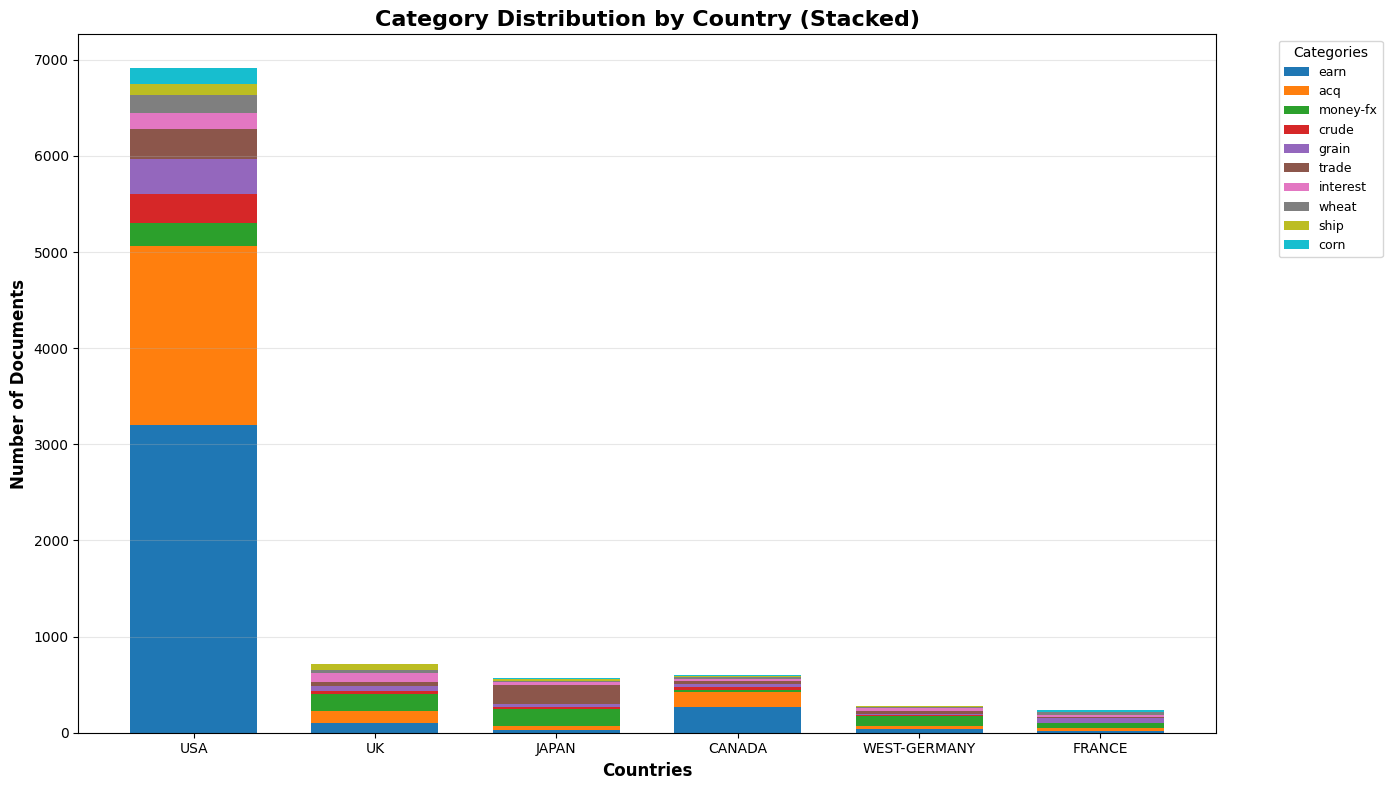

In [ ]:
# Stacked bar chart showing category distribution by country
fig, ax = plt.subplots(figsize=(14, 8))

# Get top 10 topics
top_10_topics = [t[0] for t in topic_counts.most_common(10)]

# Prepare data
x = np.arange(len(top_countries))
width = 0.7

# Stack the bars
bottom = np.zeros(len(top_countries))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, topic in enumerate(top_10_topics):
    values = [country_topic_distribution[country].get(topic, 0) for country in top_countries]
    ax.bar(x, values, width, label=topic, bottom=bottom, color=colors[idx])
    bottom += values

ax.set_xlabel('Countries', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Documents', fontsize=12, fontweight='bold')
ax.set_title('Category Distribution by Country (Stacked)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in top_countries])
ax.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

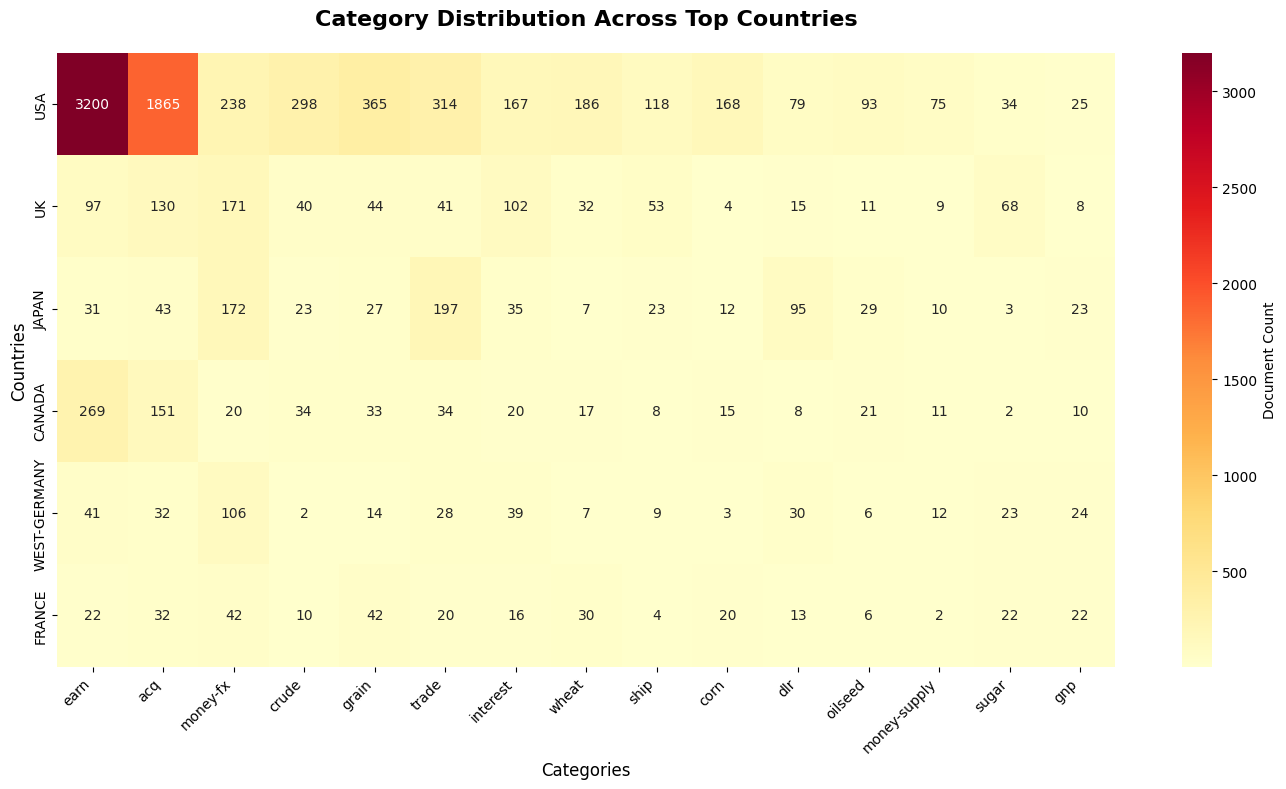

In [ ]:
# Create a heatmap showing category distribution across countries
import seaborn as sns

# Get top 15 topics overall
top_15_topics = [t[0] for t in topic_counts.most_common(15)]

# Create a matrix: rows = countries, columns = topics
heatmap_data = []
country_labels = []

for country in top_countries:
    country_labels.append(country.upper())
    row = []
    topic_dist = country_topic_distribution[country]
    for topic in top_15_topics:
        row.append(topic_dist.get(topic, 0))
    heatmap_data.append(row)

# Create DataFrame for heatmap
heatmap_df = pd.DataFrame(heatmap_data, index=country_labels, columns=top_15_topics)

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Document Count'})
plt.title('Category Distribution Across Top Countries', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Categories', fontsize=12)
plt.ylabel('Countries', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Analyze category distribution by country
# For top countries, show which categories are most common

top_countries = ['usa', 'uk', 'japan', 'canada', 'west-germany', 'france']

# Create a mapping of country -> topic counts
country_topic_distribution = {}

for country in top_countries:
    # Filter documents that mention this country
    country_docs = df_reuters[df_reuters['places'].apply(lambda x: country in x)]
    
    # Count topics in these documents
    country_topics = []
    for topics_list in country_docs['topics']:
        country_topics.extend(topics_list)
    
    topic_counts_country = Counter(country_topics)
    country_topic_distribution[country] = topic_counts_country
    
    print(f"\n{country.upper()} - Top 10 Categories:")
    print(f"Total documents: {len(country_docs)}")
    print(f"Documents with topics: {len([t for t in country_docs['topics'] if len(t) > 0])}")
    for topic, count in topic_counts_country.most_common(10):
        print(f"  {topic}: {count}")


USA - Top 10 Categories:
Total documents: 12541
Documents with topics: 6968
  earn: 3200
  acq: 1865
  grain: 365
  trade: 314
  crude: 298
  money-fx: 238
  wheat: 186
  corn: 168
  interest: 167
  ship: 118

UK - Top 10 Categories:
Total documents: 1485
Documents with topics: 820
  money-fx: 171
  acq: 130
  interest: 102
  earn: 97
  sugar: 68
  ship: 53
  grain: 44
  trade: 41
  crude: 40
  cocoa: 35

JAPAN - Top 10 Categories:
Total documents: 1136
Documents with topics: 630
  trade: 197
  money-fx: 172
  dlr: 95
  yen: 45
  acq: 43
  interest: 35
  earn: 31
  oilseed: 29
  grain: 27
  crude: 23

CANADA - Top 10 Categories:
Total documents: 1104
Documents with topics: 717
  earn: 269
  acq: 151
  gold: 48
  crude: 34
  trade: 34
  grain: 33
  oilseed: 21
  copper: 20
  money-fx: 20
  interest: 20

WEST-GERMANY - Top 10 Categories:
Total documents: 567
Documents with topics: 347
  money-fx: 106
  earn: 41
  interest: 39
  acq: 32
  dlr: 30
  trade: 28
  gnp: 24
  sugar: 23
  grain

In [ ]:
# Path to Reuters-21578 dataset
reuters_dir = "data/reuters/"